# Volatility Forecasting — Starter Notebook
### Can ML / deep-learning models forecast daily equity volatility better than classical baselines?
**BSc (Hons) Data Science & AI, IIT Guwahati — Self-guided Project**

This notebook gives you a **correct, runnable foundation**:
- Data loading + target construction
- Fully-implemented classical **baselines** (naive, rolling, EWMA, GARCH family)
- A rigorous **walk-forward evaluation harness** with RMSE, MAE, **QLIKE**, and the **Diebold–Mariano** test — no look-ahead bias

The **ML (XGBoost)** and **deep-learning (LSTM)** sections are left as **scaffolds with `TODO`s**. That modelling is the core of your project and the part the assessors want to see *you* understand — build and tune it yourself.

> **How to use:** run top to bottom, read the comments, and fill in every `# TODO`. Each section maps to a part of the report template (noted in the headers).

---


## 0. Setup & configuration
Run this once. In Colab you may need the `!pip install` line the first time.

In [1]:
# !pip install yfinance arch xgboost statsmodels scikit-learn matplotlib torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# All pipeline code now lives in the `volforecast/` package next to this notebook:
#   config / data / metrics / features / baselines / ml_xgboost / ml_lstm / evaluate / pipeline
# Edit CFG in volforecast/config.py (ticker, dates, windows, refit cadence).
from volforecast.config import CFG, EPS
CFG

{'ticker': '^GSPC',
 'start': '2008-01-01',
 'end': '2024-12-31',
 'test_frac': 0.3,
 'roll_window': 21,
 'ewma_lambda': 0.94,
 'garch_refit_every': 22,
 'garch_window': None}

## 1. Data loading  → *maps to report §4.1 Experimental Setup*
We download daily prices and compute **log returns** `r_t = ln(P_t / P_{t-1})`.

If you are offline (or Yahoo is unreachable), set `USE_SYNTHETIC = True` to generate GARCH-like
returns so you can develop the pipeline, then switch back to real data for your final run.

In [2]:
USE_SYNTHETIC = False  # set True to develop offline with simulated returns

from volforecast.data import load_returns, synthetic_returns

r = synthetic_returns() if USE_SYNTHETIC else load_returns(CFG)
print(f"{len(r)} daily returns, {r.index.min().date()} → {r.index.max().date()}")
r.head()

4277 daily returns, 2008-01-03 → 2024-12-30


Date
2008-01-03    0.000000
2008-01-04   -0.024858
2008-01-07    0.003218
2008-01-08   -0.018523
2008-01-09    0.013532
Name: ret, dtype: float64

## 2. Target construction & EDA  → *maps to report §2.1 Problem Statement*
True volatility is **latent** — you never observe it. Each model outputs a **one-day-ahead variance
forecast** for day *t*; we score it against the **realized squared return** `r_t²` as the proxy for
that day's true variance. Squared returns are noisy, which is exactly why we use the **QLIKE** loss
(robust to that noise) alongside RMSE/MAE.

Note the classic **volatility clustering** in the plots — large moves follow large moves. That
autocorrelation in `r²` is what every model here is trying to exploit.

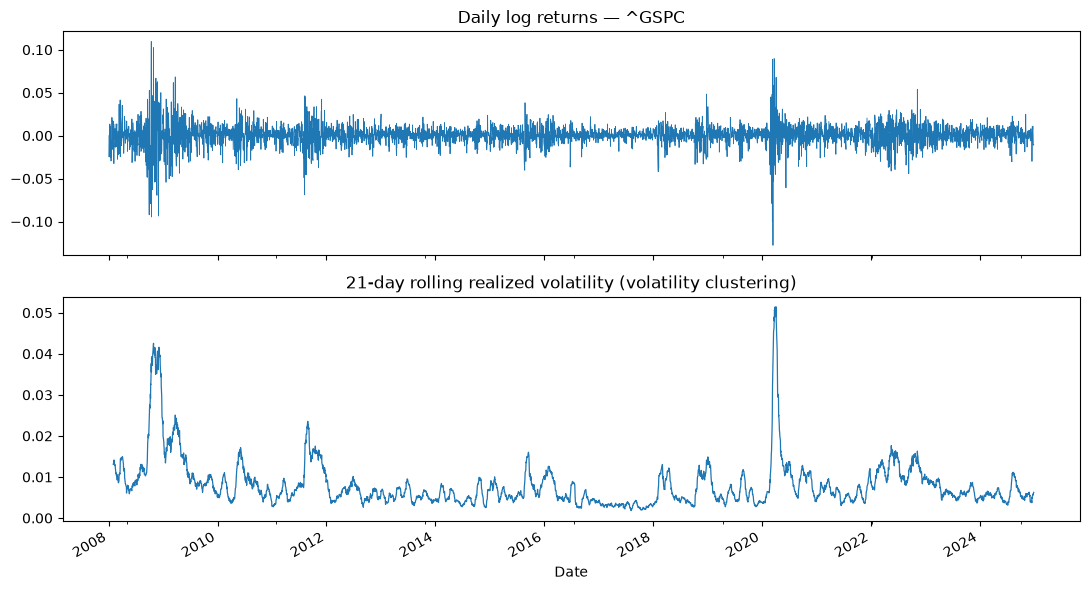

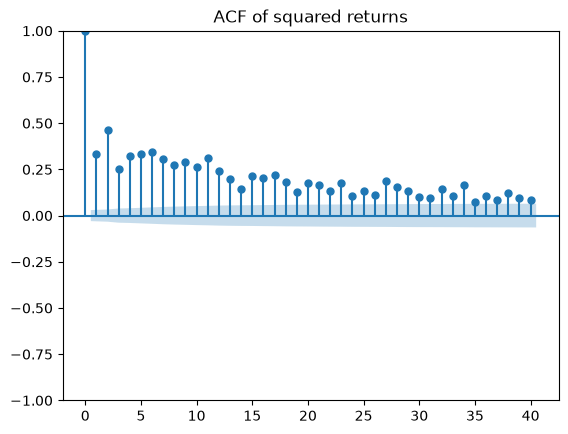

In [3]:
proxy = (r ** 2).rename("proxy_var")     # realized-variance proxy = squared return
realized_vol = np.sqrt(proxy).rename("realized_vol")

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
r.plot(ax=ax[0], lw=0.6); ax[0].set_title(f"Daily log returns — {CFG['ticker']}")
realized_vol.rolling(21).mean().plot(ax=ax[1], lw=0.9)
ax[1].set_title("21-day rolling realized volatility (volatility clustering)")
plt.tight_layout(); plt.show()

# ACF of squared returns — the signal our models exploit
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(proxy.dropna(), lags=40); plt.title("ACF of squared returns"); plt.show()


## 3. Evaluation utilities  → *maps to report §4.1 (metrics)*
**These are implemented and tested — do not change them; trust them.**

- **RMSE / MAE** are computed on the *volatility* scale (√variance) for interpretability.
- **QLIKE** is computed on the *variance* scale; it is the robust loss for a noisy proxy:
  `QLIKE = mean( p/v − ln(p/v) − 1 )` where `p` = proxy variance, `v` = forecast variance.
- **Diebold–Mariano** tests whether one model's mean loss is *significantly* lower than another's
  (with the Harvey–Leybourne–Newbold small-sample correction). A negative DM stat means model 1 is better.

In [4]:
# Implemented & tested in volforecast/metrics.py — do not change them; trust them.
from volforecast.metrics import rmse, mae, qlike_series, qlike, dm_test
from volforecast.config import test_start_index

# split index for the out-of-sample test window
test_start = test_start_index(r, CFG)
print("Train days:", test_start, " Test days:", len(r) - test_start)

Train days: 2993  Test days: 1284


## 4. Classical baselines  → *maps to report §3 Methodology & §4.2 Results*
Each function returns a full-length array of **one-day-ahead variance forecasts**, where the forecast
for day *t* uses information available only **up to day t−1** (no look-ahead). These are strong,
honest baselines — beating them is genuinely hard, which is the point of the project.

In [5]:
# Baselines live in volforecast/baselines.py — the GARCH/GJR/EGARCH recursions are
# unchanged (still mirror the `arch` package's own garch/egarch recursions exactly).
#
# run_all_forecasts (volforecast/pipeline.py) computes the cheap baselines inline and
# dispatches the five heavy, mutually-independent pipelines — GARCH(1,1), GJR-GARCH,
# EGARCH, XGBoost (§5) and the LSTM (§6) — to separate processes. These are CPU-bound
# fit loops (repeated MLE / boosting / SGD), so processes beat threads (GIL) and total
# wall-clock drops to roughly the slowest single pipeline instead of the sum of all five.
import time
from volforecast.baselines import bl_naive, bl_rolling, bl_ewma, bl_garch_family
from volforecast.pipeline import run_all_forecasts

t0 = time.perf_counter()
forecasts = run_all_forecasts(r, CFG)
print(f"all forecasts computed in {time.perf_counter() - t0:.0f}s:", list(forecasts))

  GARCH(1,1)      done  [    3s]


  GJR-GARCH(1,1)  done  [    4s]
  EGARCH(1,1)     done  [    4s]


  XGBoost         done  [   57s]


  LSTM            done  [   58s]


all forecasts computed in 59s: ['Naive', 'Rolling(21)', 'EWMA(0.94)', 'GARCH(1,1)', 'GJR-GARCH(1,1)', 'EGARCH(1,1)', 'XGBoost', 'LSTM']


## 5. ML model — XGBoost  → *scaffold, this is YOUR work (report §3.2)*
Gradient-boosted trees on engineered features.

**Design decision you must make and justify in the report:** do **not** regress raw variance with
plain squared-error loss — squared returns are extremely noisy and the model collapses (QLIKE
explodes). A sound default is to predict **log realized variance** (smoother, roughly Gaussian) and
exponentiate back. A common smoothed target is the forward/So-called realized variance over a short
window. Start from the stub below and iterate.

In [6]:
# The XGBoost pipeline lives in volforecast/features.py (make_features, make_target) and
# volforecast/ml_xgboost.py (bl_xgboost). It already ran — in parallel with the GARCH
# family — inside run_all_forecasts (§4). To iterate on features/hyper-params standalone:
#   from volforecast.ml_xgboost import bl_xgboost
#   forecasts["XGBoost"], xgb_model = bl_xgboost(r, CFG)
from volforecast.features import make_features, make_target

assert np.isfinite(forecasts["XGBoost"][test_start:]).all()
print(f"XGBoost walk-forward done: refit every {CFG['garch_refit_every']} days over the test window.")
print("features:", ", ".join(make_features(r).columns))

XGBoost walk-forward done: refit every 22 days over the test window.
features: r_lag1, r2_lag1, r_lag2, r2_lag2, r_lag3, r2_lag3, r_lag4, r2_lag4, r_lag5, r2_lag5, r_lag6, r2_lag6, r_lag7, r2_lag7, r_lag8, r2_lag8, r_lag9, r2_lag9, r_lag10, r2_lag10, rv5, rv21, absmean5


## 6. Deep learning — LSTM  → *scaffold, this is YOUR work (report §3.2)*
A sequence model over the last *L* days of returns/vol features. **Requires PyTorch**
(`pip install torch`). This is a minimal, deliberately incomplete scaffold — the architecture,
target, scaling, early stopping, and walk-forward retraining are yours to design and defend.

Watch for: (1) scale/normalize inputs; (2) predict **log-vol**, not raw variance; (3) strictly no
look-ahead when building sequences; (4) deep nets often **overfit** limited daily data — comparing
honestly against GARCH is the whole point.

In [7]:
# The LSTM pipeline lives in volforecast/ml_lstm.py (VolLSTM, make_sequences, bl_lstm).
# make_sequences now builds the (n, seq_len, n_features) windows with a vectorized
# numpy sliding_window_view instead of a per-window Python loop — verified bit-identical.
# Training details are unchanged: val split carved from the END of train (never test),
# TRAIN-only standardization, Adam + early stopping, best checkpoint restored.
# It already ran inside run_all_forecasts (§4). To iterate on the architecture standalone:
#   from volforecast.ml_lstm import bl_lstm
#   forecasts["LSTM"], lstm_model = bl_lstm(r, CFG, seq_len=20, hidden=32, layers=1)
n_lstm = int(np.isfinite(forecasts["LSTM"][test_start:]).sum())
print(f"LSTM done — forecasts['LSTM'] filled on {n_lstm} test days.")

# Stretch goal (left for you, mirrors bl_garch's structure): periodic retraining as the
# walk-forward window advances, instead of a single train/val/test fit.

LSTM done — forecasts['LSTM'] filled on 1275 test days.


## 7. Results — comparison & significance  → *maps to report §4.2 Results + §5 Discussion*
Assemble the leaderboard, then use **Diebold–Mariano** to check whether the best model is
*significantly* better than the strongest baseline, or just lucky. Refer to every table/figure in
your report text.

In [8]:
from volforecast.evaluate import build_leaderboard, dm_vs_best_baseline

leaderboard = build_leaderboard(forecasts, r, CFG)
display(leaderboard.round(6))

# --- DM test: best model vs best *baseline* (see volforecast/evaluate.py) ---
best, ref, stat, p = dm_vs_best_baseline(forecasts, leaderboard, r, CFG)
print(f"DM: {best} vs {ref}  (QLIKE)  stat={stat:.3f}  p={p:.4f}")
print(f"→ {'significant' if p<0.05 else 'NOT significant'} at 5% "
      f"({best + ' better' if stat<0 else ref + ' better'})")

,N,RMSE,MAE,QLIKE
Model,,,,
"GARCH(1,1)",1284,0.008867,0.006334,1.487913
"EGARCH(1,1)",1284,0.008521,0.006027,1.494270
"GJR-GARCH(1,1)",1284,0.008812,0.006107,1.497442
EWMA(0.94),1284,0.009343,0.006571,1.516102
XGBoost,1284,0.008162,0.005469,1.556711
Rolling(21),1284,0.009478,0.006461,1.579809
LSTM,1275,0.009649,0.005701,1.591455
Naive,1284,0.011142,0.007468,1192.687087


DM: GARCH(1,1) vs EGARCH(1,1)  (QLIKE)  stat=-0.166  p=0.8679
→ NOT significant at 5% (GARCH(1,1) better)


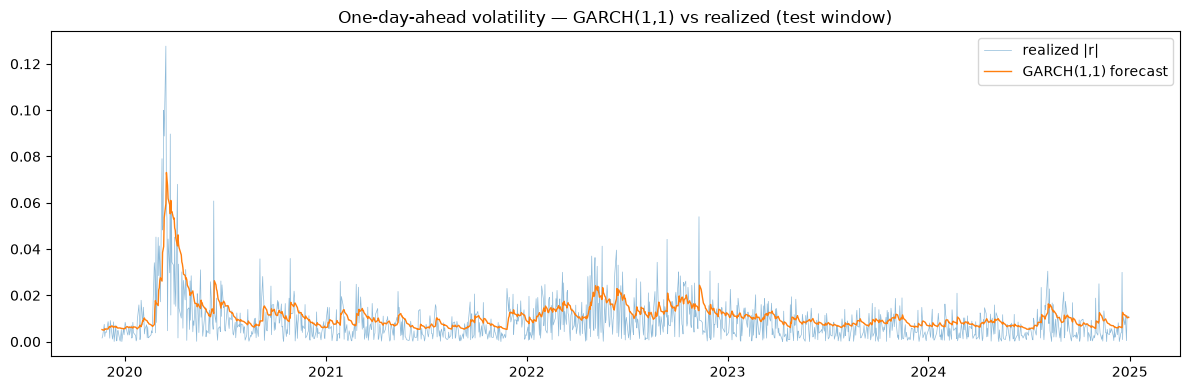

In [9]:
# Forecast vs realized volatility, best model
sl = slice(test_start, len(r))
vol_true = np.sqrt((r.values ** 2)[sl])
best_fc = np.sqrt(np.clip(forecasts[best][sl], EPS, None))
idx = r.index[sl]
plt.figure(figsize=(12, 4))
plt.plot(idx, vol_true, lw=0.5, alpha=0.5, label="realized |r|")
plt.plot(idx, best_fc, lw=1.0, label=f"{best} forecast")
plt.title(f"One-day-ahead volatility — {best} vs realized (test window)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Your TODO checklist (maps to the 80-hour plan)
- [ ] Swap in real data (`USE_SYNTHETIC = False`) and pick your primary asset; optionally a 2nd for robustness (§4.1)
- [x] Add EGARCH / GJR-GARCH baselines (leverage effect) (§3)
- [x] Convert **XGBoost** to a true walk-forward with periodic refit; engineer & **justify** features (§3.2) — refit loop done, feature justification still yours to write up
- [x] Implement & tune the **LSTM**; document architecture and training choices (§3.2) — implemented & trained with early stopping; tuning (layers/hidden/seq_len) and write-up still yours
- [ ] Fill the leaderboard; run DM tests; note which differences are significant (§4.2)
- [ ] Write the **Discussion**: *why* GARCH is hard to beat, trade-offs, honest limitations (§5)
- [ ] Push code to a public GitHub repo and link it in §7 Artifacts

**Reproducibility:** fix all seeds, log package versions, and keep the walk-forward split fixed so
your reported numbers are stable. Good luck!
